# 02 — Train & Evaluate

CourseCompass · WolfHacks 2026

Trains the decision tree that flags students at risk of finishing a course with a D or F, and evaluates it on a held-out test set.

**Run `01_explore_clean.ipynb` first.** It cleans the data, makes the train/test split and writes `cleaned_data.csv` + `feature_config.json`.

Cells marked **📊 Slide** are written to be lifted straight into the presentation.

> All data is synthetic. Model output is guidance, not a verdict.

## 1. Load the cleaned data

In [1]:
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.tree import DecisionTreeClassifier, export_text

TARGET = "at_risk"
MODEL_DIR = "../ml-service/models"
FIG_DIR = "figures"
RANDOM_STATE = 42

df = pd.read_csv("cleaned_data.csv")
with open("feature_config.json") as f:
    feature_config_in = json.load(f)

FEATURES = feature_config_in["model_features"]
print(f"Rows: {len(df)}, nulls remaining: {int(df.isnull().sum().sum())}")
print(f"Model features ({len(FEATURES)}): {FEATURES}")

Rows: 800, nulls remaining: 0
Model features (11): ['attendance_rate', 'missed_deadlines', 'on_time_submission_rate', 'avg_practice_quiz_score', 'midterm_score', 'avg_weekly_study_hours', 'flashcards_reviewed', 'avg_days_started_before_exam', 'late_night_study_pct', 'avg_sleep_hours', 'study_sessions_logged']


## 2. Train/test split — 80/20, stratified on `at_risk`

The split was made in `01_explore_clean.ipynb` with `train_test_split(test_size=0.2, stratify=at_risk, random_state=42)` and saved as the `split` column. We reuse it instead of splitting again, because the imputation medians in `01` were computed from exactly these training rows. A fresh split would let test rows influence the imputed values.

The test set (160 students) is not touched until step 7.

In [2]:
is_train = df["split"] == "train"
X_train, y_train = df.loc[is_train, FEATURES], df.loc[is_train, TARGET]
X_test, y_test = df.loc[~is_train, FEATURES], df.loc[~is_train, TARGET]

print(f"Train: {len(X_train)} rows, at_risk rate {y_train.mean():.3f}")
print(f"Test:  {len(X_test)} rows, at_risk rate {y_test.mean():.3f}")

Train: 640 rows, at_risk rate 0.278
Test:  160 rows, at_risk rate 0.275


## 3. Baseline — always predict the majority class

The simplest possible "model" predicts **not at risk** for everyone. Any real model has to beat it.

In [3]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

baseline_metrics = {
    "accuracy": float(accuracy_score(y_test, baseline_pred)),
    "recall_at_risk": float(recall_score(y_test, baseline_pred)),
}
print("=== BASELINE (most_frequent) — test set ===")
print(f"Accuracy:            {baseline_metrics['accuracy']:.4f}")
print(f"Recall (at_risk=1):  {baseline_metrics['recall_at_risk']:.4f}")

=== BASELINE (most_frequent) — test set ===
Accuracy:            0.7250
Recall (at_risk=1):  0.0000


### 📊 Slide — Why recall matters more than accuracy

The baseline scores **72.5% accuracy** while catching **zero** struggling students. Because only ~28% of students are at risk, accuracy rewards ignoring them.

The two kinds of mistake don't cost the same:

| Mistake | What happens | Cost |
|---|---|---|
| **False negative**: at-risk student marked "fine" | No warning, no study plan, they find out too late | High: a D/F or a missed withdraw deadline |
| **False positive**: fine student marked "at risk" | They get a nudge and a study plan they didn't strictly need | Low: some extra studying |

So we optimise **recall on `at_risk=1`**, meaning the share of struggling students we catch. We use `class_weight='balanced'` so the tree treats each at-risk student as roughly 2.6× as important as a not-at-risk one, matching the 72/28 class ratio. We still report precision, so we can see how many false alarms that costs.

## 4. Cross-validate `max_depth` (training split only)

For each depth in `[2, 3, 4, 5, 6, 8, None]`: `class_weight='balanced'`, `min_samples_leaf=5`, 5-fold `StratifiedKFold`, `scoring='recall'`.

A single 5-fold run turned out to be too noisy to choose a depth with: recall swings by about ±0.08 between folds, more than the gap between depths, and reshuffling the folds changes the winner. So we run the 5-fold CV **10 times with different shuffles** (50 fits per depth) and compare averages. The single unshuffled run is shown alongside for transparency.

In [4]:
DEPTHS = [2, 3, 4, 5, 6, 8, None]
N_REPEATS = 10


def make_tree(depth):
    return DecisionTreeClassifier(
        max_depth=depth, class_weight="balanced", min_samples_leaf=5, random_state=RANDOM_STATE
    )


rows = []
for depth in DEPTHS:
    single = cross_val_score(make_tree(depth), X_train, y_train, cv=StratifiedKFold(5), scoring="recall")
    val_recall, train_recall = [], []
    for seed in range(N_REPEATS):
        r = cross_validate(
            make_tree(depth), X_train, y_train,
            cv=StratifiedKFold(5, shuffle=True, random_state=seed),
            scoring="recall", return_train_score=True,
        )
        val_recall.extend(r["test_score"])
        train_recall.extend(r["train_score"])
    val_recall = np.array(val_recall)
    rows.append({
        "max_depth": "None" if depth is None else depth,
        "single_5fold_recall": single.mean(),
        "cv_recall": val_recall.mean(),
        "cv_recall_se": val_recall.std() / np.sqrt(len(val_recall)),
        "train_recall": np.mean(train_recall),
        "leaves": make_tree(depth).fit(X_train, y_train).get_n_leaves(),
    })

cv_results = pd.DataFrame(rows)
cv_results["overfit_gap"] = cv_results["train_recall"] - cv_results["cv_recall"]
print(cv_results.round(4).to_string(index=False))

max_depth  single_5fold_recall  cv_recall  cv_recall_se  train_recall  leaves  overfit_gap
        2               0.8146     0.7804        0.0170        0.8435       4       0.0631
        3               0.7871     0.8096        0.0108        0.8945       8       0.0848
        4               0.8098     0.7712        0.0139        0.9076      14       0.1364
        5               0.8211     0.7642        0.0116        0.9274      24       0.1632
        6               0.7811     0.7494        0.0133        0.9449      32       0.1955
        8               0.8040     0.7414        0.0128        0.9518      44       0.2104
     None               0.8040     0.7403        0.0127        0.9515      44       0.2112


## 5. Pick the depth

1. Only consider depths **3–5**. Beyond that, the tree is too big to explain to a student in a sentence.
2. Find the depth with the highest mean CV recall.
3. Choose the **shallowest** depth within one standard error of it (the "one-standard-error rule"). If a simpler tree is statistically as good, we take the simpler one.

In [5]:
CANDIDATE_DEPTHS = [3, 4, 5]
candidates = cv_results[cv_results["max_depth"].isin(CANDIDATE_DEPTHS)]
best = candidates.loc[candidates["cv_recall"].idxmax()]
threshold = best["cv_recall"] - best["cv_recall_se"]
BEST_DEPTH = int(candidates.loc[candidates["cv_recall"] >= threshold, "max_depth"].min())

print(f"Highest CV recall in {CANDIDATE_DEPTHS}: depth {int(best['max_depth'])} "
      f"({best['cv_recall']:.4f} ± {best['cv_recall_se']:.4f} SE)")
print(f"Shallowest depth with CV recall >= {threshold:.4f}: depth {BEST_DEPTH}")

Highest CV recall in [3, 4, 5]: depth 3 (0.8096 ± 0.0108 SE)
Shallowest depth with CV recall >= 0.7988: depth 3


## 6. Train the final model and check for overfitting

In [6]:
model = make_tree(BEST_DEPTH)
model.fit(X_train, y_train)

train_acc = float(model.score(X_train, y_train))
test_acc = float(model.score(X_test, y_test))
print(f"max_depth={BEST_DEPTH}, leaves={model.get_n_leaves()}")
print(f"Train accuracy:  {train_acc:.4f}")
print(f"Test accuracy:   {test_acc:.4f}")
print(f"Overfitting gap: {train_acc - test_acc:.4f}  (rule of thumb: worry above 0.10)")

max_depth=3, leaves=8
Train accuracy:  0.8609
Test accuracy:   0.7937
Overfitting gap: 0.0672  (rule of thumb: worry above 0.10)


### 📊 Slide — Overfitting: why a 3-level tree

A decision tree can keep splitting until it memorises the training data. The depth table in step 4 shows that happening:

- **Training recall keeps rising with depth** (≈0.84 at depth 2 → ≈0.95 unlimited).
- **Validation recall peaks at depth 3 and then falls** (≈0.81 → ≈0.74). The deeper trees are learning noise specific to the training students.
- The **gap** between the two widens from ≈0.08 at depth 3 to ≈0.21 for an unlimited tree.

Guards we used:
- `max_depth` chosen by **repeated** cross-validation on training data only. The test set never influenced it.
- `min_samples_leaf=5`, so no rule rests on fewer than 5 students.
- The one-standard-error rule, which prefers the simpler tree when the scores are tied.

Result: train accuracy **0.861** vs test accuracy **0.794**, a gap of **0.067**, under the 0.10 warning line. The model is also small enough to explain (8 leaves, 4 features).

**Caveat:** with only 44 at-risk students in the test set, each student moves test recall by ~2.3 points. The cross-validated recall (~0.81) is the more stable estimate.

## 7. Evaluate on the held-out test set

In [7]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "recall_at_risk": float(recall_score(y_test, y_pred)),
    "precision_at_risk": float(precision_score(y_test, y_pred)),
    "f1_at_risk": float(f1_score(y_test, y_pred)),
    "roc_auc": float(roc_auc_score(y_test, y_proba)),
}
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("=== FINAL MODEL — TEST SET ===")
for k, v in metrics.items():
    print(f"{k:18s} {v:.4f}")
print(f"\nConfusion matrix:\n  TN={tn}  FP={fp}\n  FN={fn}  TP={tp}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Not at risk", "At risk"]))

=== FINAL MODEL — TEST SET ===
accuracy           0.7937
recall_at_risk     0.7727
precision_at_risk  0.5965
f1_at_risk         0.6733
roc_auc            0.8658

Confusion matrix:
  TN=93  FP=23
  FN=10  TP=34

Classification report:
              precision    recall  f1-score   support

 Not at risk       0.90      0.80      0.85       116
     At risk       0.60      0.77      0.67        44

    accuracy                           0.79       160
   macro avg       0.75      0.79      0.76       160
weighted avg       0.82      0.79      0.80       160



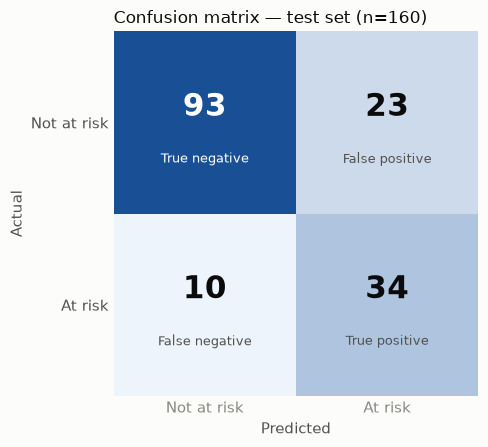

In [8]:
# Shared chart styling (reference palette, light surface)
SURFACE, INK, INK_2, MUTED, GRID, BLUE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#2a78d6"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": INK_2,
    "axes.edgecolor": GRID, "font.size": 11,
})
import os
os.makedirs(FIG_DIR, exist_ok=True)

seq_blue = LinearSegmentedColormap.from_list("seq_blue", ["#eef4fc", "#184f95"])
fig, ax = plt.subplots(figsize=(5.5, 4.6))
ax.imshow(cm, cmap=seq_blue)
labels = [["True negative", "False positive"], ["False negative", "True positive"]]
for i in range(2):
    for j in range(2):
        dark = cm[i, j] > cm.max() * 0.5
        ax.text(j, i - 0.08, f"{cm[i, j]}", ha="center", va="center", fontsize=22, fontweight="bold",
                color="#ffffff" if dark else INK)
        ax.text(j, i + 0.2, labels[i][j], ha="center", va="center", fontsize=9,
                color="#ffffff" if dark else INK_2)
ax.set_xticks([0, 1], ["Not at risk", "At risk"])
ax.set_yticks([0, 1], ["Not at risk", "At risk"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — test set (n={len(y_test)})", loc="left", fontsize=12)
for s in ax.spines.values():
    s.set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/confusion_matrix.png", dpi=200)
plt.show()

### 📊 Slide — Baseline vs model

In [9]:
comparison = pd.DataFrame({
    "Majority-class baseline": [baseline_metrics["accuracy"], baseline_metrics["recall_at_risk"], 0.0, 0.0, 0.5],
    f"Decision tree (depth {BEST_DEPTH})": [metrics["accuracy"], metrics["recall_at_risk"],
                                           metrics["precision_at_risk"], metrics["f1_at_risk"], metrics["roc_auc"]],
}, index=["Accuracy", "Recall (at_risk=1)", "Precision (at_risk=1)", "F1 (at_risk=1)", "ROC-AUC"])
comparison.round(3)

,Majority-class baseline,Decision tree (depth 3)
Accuracy,0.725,0.794
Recall (at_risk=1),0.000,0.773
Precision (at_risk=1),0.000,0.596
F1 (at_risk=1),0.000,0.673
ROC-AUC,0.500,0.866


- The baseline catches **0 of 44** at-risk students. The tree catches **34 of 44** (recall **0.77**), and accuracy also goes *up*, from 0.725 to 0.794.
- The cost is **23 false alarms** out of 116 students who were fine (precision 0.60). A false alarm means a supportive nudge and a study plan, so we accept it.
- **ROC-AUC 0.87**: if you pick one at-risk and one not-at-risk student at random, the model gives the at-risk one a higher risk score 87% of the time. The baseline is a coin flip (0.5).
- **10 students were missed** (false negatives). This is why the app also uses the student's own self-ratings and projected grade, and never relies on the model alone.

## 8. Feature importances

Gini importance: how much each feature reduces impurity across all the splits that use it. Importances sum to 1, and a feature with 0 is never used by the tree.

In [10]:
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("=== FEATURE IMPORTANCES (top 12) ===")
print(importances.head(12).round(4).to_string())

used_features = importances[importances > 0].index.tolist()
unused_features = importances[importances == 0].index.tolist()
print(f"\nUsed by the tree: {used_features}")
print(f"Never used:       {unused_features}")

=== FEATURE IMPORTANCES (top 12) ===
midterm_score                   0.5891
on_time_submission_rate         0.2151
attendance_rate                 0.1143
late_night_study_pct            0.0816
missed_deadlines                0.0000
avg_practice_quiz_score         0.0000
avg_weekly_study_hours          0.0000
flashcards_reviewed             0.0000
avg_days_started_before_exam    0.0000
avg_sleep_hours                 0.0000
study_sessions_logged           0.0000

Used by the tree: ['midterm_score', 'on_time_submission_rate', 'attendance_rate', 'late_night_study_pct']
Never used:       ['missed_deadlines', 'avg_practice_quiz_score', 'avg_weekly_study_hours', 'flashcards_reviewed', 'avg_days_started_before_exam', 'avg_sleep_hours', 'study_sessions_logged']


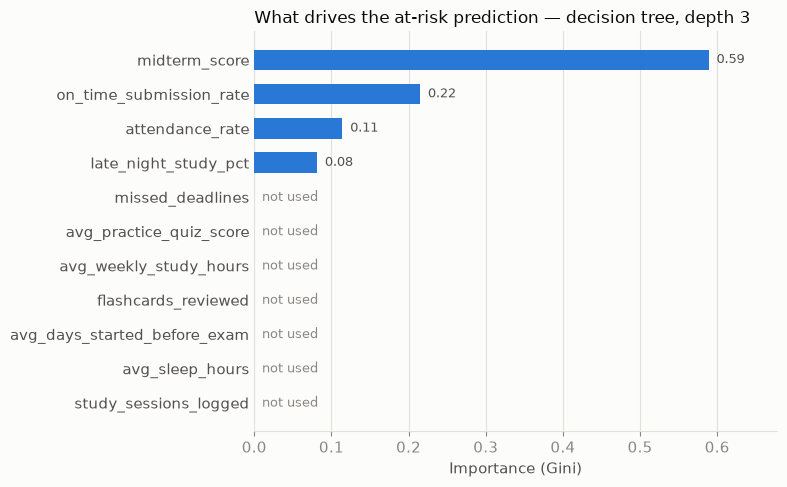

In [11]:
top = importances.head(12).iloc[::-1]  # largest at top
fig, ax = plt.subplots(figsize=(8, 5))
colors = [BLUE if v > 0 else GRID for v in top.values]
ax.barh(top.index, top.values, color=colors, height=0.6)
for y, v in enumerate(top.values):
    ax.text(v + 0.01, y, f"{v:.2f}" if v > 0 else "not used", va="center", fontsize=9,
            color=INK_2 if v > 0 else MUTED)
ax.set_xlim(0, max(top.values) * 1.15)
ax.set_xlabel("Importance (Gini)")
ax.set_title(f"What drives the at-risk prediction — decision tree, depth {BEST_DEPTH}", loc="left", fontsize=12)
ax.xaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/feature_importances.png", dpi=200)
plt.show()

## What the tree learned

In [12]:
tree_rules = export_text(model, feature_names=FEATURES)
print(tree_rules)

# How many training students land in each leaf, and how many of them were actually at risk
leaf_stats = (
    pd.DataFrame({"leaf": model.apply(X_train), "at_risk": y_train.values})
    .groupby("leaf")["at_risk"].agg(students="size", actually_at_risk="sum", rate="mean")
)
leaf_stats["flagged"] = [int(model.tree_.value[leaf].argmax()) for leaf in leaf_stats.index]
leaf_stats.round(2)

|--- midterm_score <= 64.50
|   |--- on_time_submission_rate <= 0.80
|   |   |--- attendance_rate <= 0.94
|   |   |   |--- class: 1
|   |   |--- attendance_rate >  0.94
|   |   |   |--- class: 0
|   |--- on_time_submission_rate >  0.80
|   |   |--- late_night_study_pct <= 0.37
|   |   |   |--- class: 0
|   |   |--- late_night_study_pct >  0.37
|   |   |   |--- class: 1
|--- midterm_score >  64.50
|   |--- attendance_rate <= 0.78
|   |   |--- on_time_submission_rate <= 0.89
|   |   |   |--- class: 1
|   |   |--- on_time_submission_rate >  0.89
|   |   |   |--- class: 0
|   |--- attendance_rate >  0.78
|   |   |--- on_time_submission_rate <= 0.72
|   |   |   |--- class: 1
|   |   |--- on_time_submission_rate >  0.72
|   |   |   |--- class: 0



,students,actually_at_risk,rate,flagged
leaf,,,,
3,139,110,0.79,1
4,6,1,0.17,0
6,107,19,0.18,0
7,33,22,0.67,1
10,28,13,0.46,1
11,7,0,0.00,0
13,11,5,0.45,1
14,309,8,0.03,0


### 📊 Slide — What the tree learned, in plain English

**The midterm comes first.** The first question the tree asks is whether the midterm was **64.5 or below**. On its own, that accounts for over half the model's decision-making.

**If the midterm was 64.5 or below:**
- …and **80% or fewer assignments were on time** (with attendance under 94%) → **at risk**. This is the biggest at-risk group: 110 of 139 training students in it really did finish with a D/F.
- …but **more than 80% were on time** → mostly fine, **unless more than 37% of studying happens between midnight and 4 a.m.** Then 22 of 33 were at risk.

**If the midterm was above 64.5:**
- …and **attendance was above 78% and more than 72% of work was on time** → **not at risk**. This is the largest and safest group: only 8 of 309 ended up with a D/F.
- …but **skipping class** (attendance 78% or lower) together with **late submissions** (89% or fewer on time) → flagged. About half of those students were at risk, and because missing one costs more, the tree leans toward a warning.
- …or attending class but with **72% or fewer assignments on time** → also flagged (again about half were at risk).

**In one sentence:** a weak midterm, late assignments and missed classes are the warning signs. Late-night cramming tips a borderline student over the edge.

**What it doesn't use:** sleep, weekly study hours, flashcards, practice-quiz scores, missed-deadline counts and session counts never appear in the tree. Mostly that's because the four features above already carry the same signal (for example, missed deadlines and on-time rate overlap). The app can still give advice about those habits, but labels it general study advice, not a reason the model flagged the student.

### 📊 Slide — Limitations & responsible use

- **Synthetic data.** Trained on 800 synthetic records, so real students may differ. Recall is about 77% on the test set and about 81% in cross-validation, which means roughly 1 in 5 at-risk students will be missed.
- **Midterm-heavy.** About 59% of the decision rests on `midterm_score`, so predictions made before the midterm are much less reliable.
- **Guidance, not a verdict.** Every risk card says so, and a withdraw recommendation always comes with "talk to your advisor first".
- **Explanations are honest.** Each student's "why" comes from the actual 2–3 questions the tree asked about *them*, so it never mentions a feature the model didn't use.
- **No demographics.** Course and class year are not model inputs. Students are flagged by what they're doing, not by who they are.

## 9. Export the model and config for the ML service

- `tree_v1.joblib`: the trained `DecisionTreeClassifier`.
- `model_config.json`: input feature order, imputation values, metrics, used/unused features and the tree rules. The ML service loads both at startup.

In [13]:
joblib.dump(model, f"{MODEL_DIR}/tree_v1.joblib")

model_config = {
    "model_version": "tree_v1",
    "target": TARGET,
    "features": FEATURES,
    "used_features": used_features,
    "unused_features": unused_features,
    "imputation_values": feature_config_in["imputation_values"],
    "hyperparameters": {
        "max_depth": BEST_DEPTH,
        "class_weight": "balanced",
        "min_samples_leaf": 5,
        "random_state": RANDOM_STATE,
    },
    "depth_selection": "5-fold StratifiedKFold recall, repeated with 10 shuffles; one-standard-error rule over depths 3-5",
    "cv_results": cv_results.to_dict(orient="records"),
    "metrics": {
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        **metrics,
        "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
    },
    "baseline_metrics": baseline_metrics,
    "feature_importances": importances[importances > 0].round(4).to_dict(),
    "tree_rules": tree_rules,
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "trained_on": "WolfHacks 2026 synthetic student outcomes",
}
with open(f"{MODEL_DIR}/model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)

print(f"Exported {MODEL_DIR}/tree_v1.joblib and {MODEL_DIR}/model_config.json")

Exported ../ml-service/models/tree_v1.joblib and ../ml-service/models/model_config.json
